# Finite-sample case

1. 
   1. generate a synthetic dataset of larger size, where each battle is sampled via: (1) unordered pair {x,y}~empirical dist of pairs; (2) generate an outcome x>y or x<y according to: p(x>y)=E_{u~D}[sigma(beta*(u_x-u_y))]. Run the ranking methods on this synthetic dataset, and for each beta plot mean and standard error of distortion with k=10 trials

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import expit
from scipy.optimize import linprog

In [9]:
# Empirical distribution over unordered pairs from the observed battles
pair_counts = {}
for w, l in zip(pw.winners, pw.losers):
    pair = (min(w, l), max(w, l))
    pair_counts[pair] = pair_counts.get(pair, 0) + 1

pairs = np.array(list(pair_counts.keys()), dtype=int)   # shape (n_pairs, 2)
counts = np.array([pair_counts[tuple(p)] for p in pairs], dtype=float)
pair_distr = counts / counts.sum()

print(f"Unique unordered pairs observed: {len(pairs)}")
print(f"Total battles: {len(pw.winners)}")

# True ranking and average utilities from population model
avg_utils  = population.avg_utilities
true_ranking = np.argsort(-avg_utils)

def theoretical_P(utilities, voter_dist, beta):
    """Infinite-sample win-rate matrix from population utilities."""
    V, C = utilities.shape
    P = np.zeros((C, C), dtype=float)
    for v, u in enumerate(utilities):
        diffs = u[:, None] - u[None, :]
        P += voter_dist[v] * expit(beta * diffs)
    np.fill_diagonal(P, 0.5)
    return P

Unique unordered pairs observed: 435
Total battles: 37454


In [10]:
from utils_3 import PairwiseData, Population

import os
for k in ["HF_HOME", "HF_HUB_CACHE", "HF_DATASETS_CACHE", "XDG_CACHE_HOME"]:
    print(k, os.environ.get(k))

from datasets import load_dataset

ds = load_dataset(
    "lmarena-ai/arena-human-preference-140k") 
ds = dict(ds)

pw = PairwiseData(ds, M=30, N=30)
population = Population(pw)

HF_HOME /home/jennifer/scratch/hf
HF_HUB_CACHE None
HF_DATASETS_CACHE /home/jennifer/scratch/hf/datasets
XDG_CACHE_HOME None


100%|██████████| 30/30 [00:00<00:00, 34.04it/s]


In [11]:
def sample_synthetic_battles(pairs, pair_distr, P_true, T, rng):
    """Sample T battles: pair ~ pair_distr, outcome ~ Bernoulli(P_true[x,y])."""
    chosen = rng.choice(len(pairs), size=T, p=pair_distr)
    xs, ys = pairs[chosen, 0], pairs[chosen, 1]
    probs = P_true[xs, ys]
    x_wins = rng.random(T) < probs
    winners = np.where(x_wins, xs, ys)
    losers  = np.where(x_wins, ys, xs)
    return winners, losers


def empirical_win_rate_matrix(winners, losers, M):
    """Build P_emp[i,j] = fraction of i-vs-j battles won by i."""
    wins  = np.zeros((M, M), dtype=float)
    np.add.at(wins, (winners, losers), 1)
    total = wins + wins.T
    with np.errstate(invalid='ignore'):
        P_emp = np.where(total > 0, wins / total, 0.5)
    np.fill_diagonal(P_emp, 0.5)
    return P_emp


def maximal_lottery_from_P(P, tie_tol=1e-9):
    """Solve for the maximal lottery directly from a win-rate matrix."""
    C = P.shape[0]
    margins = P - P.T
    result = linprog(
        c=np.zeros(C),
        A_ub=-margins.T,
        b_ub=np.zeros(C),
        A_eq=np.ones((1, C)),
        b_eq=[1.0],
        bounds=[(0.0, 1.0)] * C,
        method='highs',
    )
    if not result.success:
        raise RuntimeError(f"LP failed: {result.message}")
    lottery = np.clip(result.x, 0, None)
    lottery[lottery < tie_tol] = 0.0
    lottery /= lottery.sum()
    return lottery


def borda_from_P(P, cand_dist):
    return np.argsort(-(P @ cand_dist))


def borda_peeling_from_P(P, cand_dist):
    C = P.shape[0]
    remaining = list(range(C))
    ranking = []
    while remaining:
        rem = np.array(remaining)
        P_rem = P[np.ix_(rem, rem)]
        cd_rem = cand_dist[rem] / cand_dist[rem].sum()
        winner_local = int(np.argmax(P_rem @ cd_rem))
        ranking.append(remaining[winner_local])
        remaining.pop(winner_local)
    return np.array(ranking, dtype=int)


def copeland_from_P(P, cand_dist, tie_tol=1e-9):
    margins = P - P.T
    wins   = (margins >  tie_tol).astype(float)
    losses = (margins < -tie_tol).astype(float)
    np.fill_diagonal(wins, 0); np.fill_diagonal(losses, 0)
    scores = wins @ cand_dist - losses @ cand_dist
    return np.argsort(-scores)


def copeland_peeling_from_P(P, cand_dist, tie_tol=1e-9):
    C = P.shape[0]
    remaining = list(range(C))
    ranking = []
    while remaining:
        rem = np.array(remaining)
        P_rem = P[np.ix_(rem, rem)]
        cd_rem = cand_dist[rem] / cand_dist[rem].sum()
        margins = P_rem - P_rem.T
        wins   = (margins >  tie_tol).astype(float)
        losses = (margins < -tie_tol).astype(float)
        np.fill_diagonal(wins, 0); np.fill_diagonal(losses, 0)
        scores = wins @ cd_rem - losses @ cd_rem
        winner_local = int(np.argmax(scores))
        ranking.append(remaining[winner_local])
        remaining.pop(winner_local)
    return np.array(ranking, dtype=int)


def ml_argmax_peeling_from_P(P):
    C = P.shape[0]
    remaining = list(range(C))
    ranking = []
    while remaining:
        rem = np.array(remaining)
        try:
            lottery = maximal_lottery_from_P(P[np.ix_(rem, rem)])
            winner_local = int(np.argmax(lottery))
        except RuntimeError:
            winner_local = 0
        ranking.append(remaining[winner_local])
        remaining.pop(winner_local)
    return np.array(ranking, dtype=int)

In [12]:
from utils_3 import leaderboard_dist

betas = [0.1, 0.5, 1.0, 2.0, 3.0, 5.0, 10.0, 20.0, 50.0, 100.0]
T     = 10_000   # synthetic battles per trial
k     = 10       # trials per beta
M     = pw.M
cand_dist = pw.candidate_distr  # empirical marginal over candidates

methods = ['borda', 'borda_peeling', 'copeland', 'copeland_peeling', 'ml_argmax_peeling']
results = {m: [] for m in methods}   # results[m][beta_idx] = array of k distortions

rng = np.random.default_rng(0)

for b_idx, beta in enumerate(betas):
    P_true = theoretical_P(population.population_utilities, population.voter_distr, beta)
    trial_dists = {m: [] for m in methods}

    for trial in range(k):
        winners, losers = sample_synthetic_battles(pairs, pair_distr, P_true, T, rng)
        P_emp = empirical_win_rate_matrix(winners, losers, M)

        trial_dists['borda'].append(
            leaderboard_dist(borda_from_P(P_emp, cand_dist), true_ranking, avg_utils)[0])
        trial_dists['borda_peeling'].append(
            leaderboard_dist(borda_peeling_from_P(P_emp, cand_dist), true_ranking, avg_utils)[0])
        trial_dists['copeland'].append(
            leaderboard_dist(copeland_from_P(P_emp, cand_dist), true_ranking, avg_utils)[0])
        trial_dists['copeland_peeling'].append(
            leaderboard_dist(copeland_peeling_from_P(P_emp, cand_dist), true_ranking, avg_utils)[0])
        trial_dists['ml_argmax_peeling'].append(
            leaderboard_dist(ml_argmax_peeling_from_P(P_emp), true_ranking, avg_utils)[0])

    for m in methods:
        results[m].append(trial_dists[m])

    print(f"beta={beta:6.1f}  "
          + "  ".join(f"{m}={np.mean(trial_dists[m]):.3f}" for m in methods))

# convert to arrays: shape (n_betas, k)
results = {m: np.array(results[m]) for m in methods}

beta=   0.1  borda=1.560  borda_peeling=1.540  copeland=1.482  copeland_peeling=1.470  ml_argmax_peeling=1.999
beta=   0.5  borda=1.078  borda_peeling=1.088  copeland=1.135  copeland_peeling=1.142  ml_argmax_peeling=1.209
beta=   1.0  borda=1.019  borda_peeling=1.024  copeland=1.038  copeland_peeling=1.043  ml_argmax_peeling=1.091
beta=   2.0  borda=1.011  borda_peeling=1.015  copeland=1.050  copeland_peeling=1.052  ml_argmax_peeling=1.064
beta=   3.0  borda=1.009  borda_peeling=1.013  copeland=1.017  copeland_peeling=1.018  ml_argmax_peeling=1.052
beta=   5.0  borda=1.009  borda_peeling=1.009  copeland=1.029  copeland_peeling=1.031  ml_argmax_peeling=1.038
beta=  10.0  borda=1.009  borda_peeling=1.010  copeland=1.011  copeland_peeling=1.011  ml_argmax_peeling=1.012
beta=  20.0  borda=1.010  borda_peeling=1.009  copeland=1.011  copeland_peeling=1.014  ml_argmax_peeling=1.012
beta=  50.0  borda=1.008  borda_peeling=1.008  copeland=1.011  copeland_peeling=1.012  ml_argmax_peeling=1.012
b

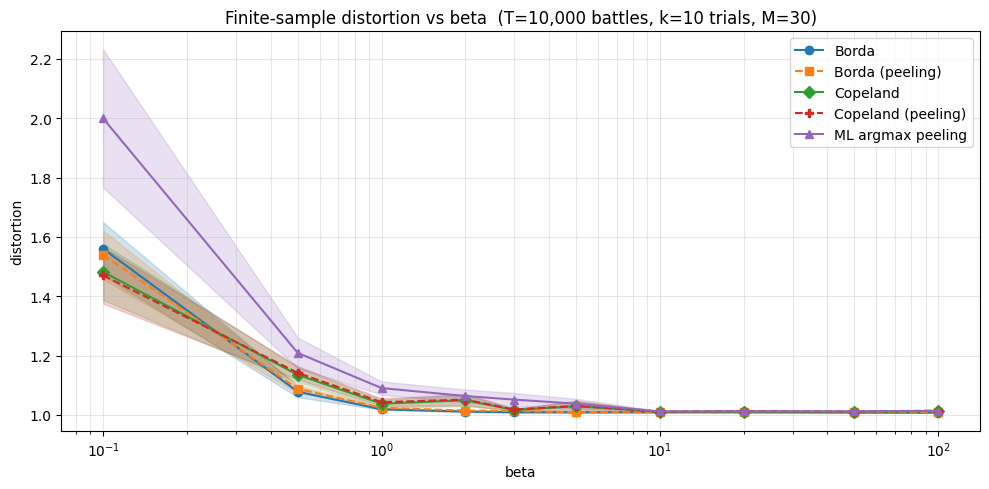

In [13]:
style = {
    'borda':             dict(marker='o', linestyle='-',  color='C0', label='Borda'),
    'borda_peeling':     dict(marker='s', linestyle='--', color='C1', label='Borda (peeling)'),
    'copeland':          dict(marker='D', linestyle='-',  color='C2', label='Copeland'),
    'copeland_peeling':  dict(marker='P', linestyle='--', color='C3', label='Copeland (peeling)'),
    'ml_argmax_peeling': dict(marker='^', linestyle='-',  color='C4', label='ML argmax peeling'),
}

means = {m: results[m].mean(axis=1) for m in methods}
ses   = {m: results[m].std(axis=1) / np.sqrt(k) for m in methods}

fig, ax = plt.subplots(figsize=(10, 5))
for m, kw in style.items():
    ax.plot(betas, means[m], **kw)
    ax.fill_between(betas,
                    means[m] - ses[m],
                    means[m] + ses[m],
                    alpha=0.2, color=kw['color'])

ax.set_xscale('log')
ax.set_xlabel('beta')
ax.set_ylabel('distortion')
ax.set_title(f'Finite-sample distortion vs beta  (T={T:,} battles, k={k} trials, M={M})')
ax.legend()
ax.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.show()